In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os
sys.path.append("../")
sys.path.append("../objs/")
sys.path.append("src/mad")

In [4]:
os.getcwd(), sys.path

('/app/notebooks',
 ['/usr/local/lib/python312.zip',
  '/usr/local/lib/python3.12',
  '/usr/local/lib/python3.12/lib-dynload',
  '',
  '/app/.venv/lib/python3.12/site-packages',
  '/app/src',
  '../',
  '../objs/',
  'src/mad'])

In [52]:
import numpy as np
from numpy.typing import NDArray
from mad.objs.common_schemas import MovableObject
from dataclasses import dataclass, asdict, field
from mad.objs.planets import Planet, PlanetConfig
from mad.objs.constants import EARTH_SETTINGS, G
import matplotlib.pyplot as plt

import scipy.integrate as sci

from copy import deepcopy

In [53]:
obj1 = MovableObject(position=[1, 1])
obj2 = MovableObject(position=[1, 0])

obj1

MovableObject at [1 1], velocity [0 0], active.

In [54]:
obj1.magnitude, obj1.norm, obj1.distance(obj2)

(np.float64(1.4142135623730951),
 array([0.70710678, 0.70710678]),
 np.float64(1.0))

In [109]:
EARTH_SETTINGS["position"] = np.asarray([0.0, 0.0])

earth = Planet(PlanetConfig(**EARTH_SETTINGS))

earth.escape_velocity, earth.gravity_at_surface

(np.float64(11185.79353278485), np.float64(9.819649737724955))

In [155]:
@dataclass
class ProjectileConfig:
    position: list[float]
    mass: float
    velocity: list[float] | None = None
    name: str = "Projectile"

    @property
    def to_dict(self):
        return asdict(self)
    
    def __post_init__(self):
        if not self.velocity:
            self.velocity = [0.0] * len(self.position)

projectile_cfg = ProjectileConfig(
    **{"position": [earth.radius + 100, 0.0], "mass": 0.64, "velocity": [100, np.sqrt(G * earth.mass / earth.radius) * 1.1]}
)

@dataclass
class History:
    position: list = field()

In [ ]:
class Projectile(MovableObject):
    def __init__(self, config: ProjectileConfig):
        super().__init__(**config.to_dict)
        self.config = config
        self.history = History(position = [config.position])

    @property
    def pos_vel_to_numpy(self):
        return np.concatenate([self.position, self.velocity])
    
    def reset(self):
        super().__init__(**self.config.to_dict)
        self.history = History(position = [self.config.position])

    
    def derivatives(self, states:NDArray, t:NDArray, planet:Planet) -> NDArray:

        pos = states[:2]
        vel = states[2:]

        total_force = np.zeros_like(pos)

        r_vec = pos - planet.position
        dist = np.linalg.norm(r_vec)

        if dist > planet.radius:
            Fg_mag = G * self.mass * planet.mass / dist**2
            Fg = -Fg_mag * r_vec / dist  
            total_force += Fg
            acc = total_force / self.mass
        else: 
            acc=np.asarray([0.0, 0.0])

        return np.concatenate([vel, acc])
    
    # We keep t for compatibility with ODE solvers.
    def step(self, dt: float, t: NDArray, planet:Planet):
        
        deriv = self.derivatives(self.pos_vel_to_numpy, t, planet)
        acc = deriv[2:]
        self.velocity += acc * dt
        self.position += self.velocity * dt

        self.history.position.append(self.position.tolist())


proj = Projectile(projectile_cfg)

proj.pos_vel_to_numpy

array([6.37110000e+06, 0.00000000e+00, 1.00000000e+02, 8.70050551e+03])

In [157]:
stateinitial = proj.pos_vel_to_numpy
# stateinitial[0] += 100

##Time window
period = 2 * np.pi / np.sqrt(G * earth.mass) * earth.radius ** (3.0 / 2.0) * 1.5
tout = np.linspace(0, period, 1000)

dt = period / 1000

period, dt

(np.float64(7591.488377479438), np.float64(7.591488377479438))

In [158]:
# Numerical Integration Call
stateout = sci.odeint(proj.derivatives, stateinitial, tout, args=(earth,))

xout = stateout[:, 0]
zout = stateout[:, 1]

# Steps integration
proj.position = stateinitial[:2]

proj.position, proj.velocity

(array([6371100.,       0.]), array([ 100.        , 8700.50550598]))

In [159]:
for _ in range (len(tout)):
    proj.step(dt, tout, earth)


In [160]:
proj.history.position

[[6371100.0, 0.0],
 [6371293.2533558635, 66049.7864268679],
 [6370920.736766157, 132093.70764198276],
 [6369982.657583949, 198125.902567785],
 [6368479.304844561, 264140.51576067926],
 [6366411.049095563, 330131.69890612096],
 [6363778.342191462, 396093.612308006],
 [6360581.717053303, 462020.42637135903],
 [6356821.787393417, 527906.3230773254],
 [6352499.247405641, 593745.4974494814],
 [6347614.871421281, 659532.1590104927],
 [6342169.513531222, 725260.5332281591],
 [6336164.1071745185, 790924.8629499025],
 [6329599.664693926, 856519.4098247703],
 [6322477.276858786, 922038.4557120388],
 [6314798.112355753, 987476.3040755267],
 [6306563.417247868, 1052827.2813627394],
 [6297774.514402507, 1118085.738367993],
 [6288432.8028887585, 1183246.0515786798],
 [6278539.757344827, 1248302.6245038672],
 [6268096.927316055, 1313249.888984438],
 [6257105.936564209, 1378082.3064840082],
 [6245568.482348689, 1442794.3693598812],
 [6233486.334680321, 1507380.6021133212],
 [6220861.335548454, 1571835

In [161]:
sim = np.asarray(proj.history.position)

xsim, zsim = sim[:, 0], sim[:, 1]

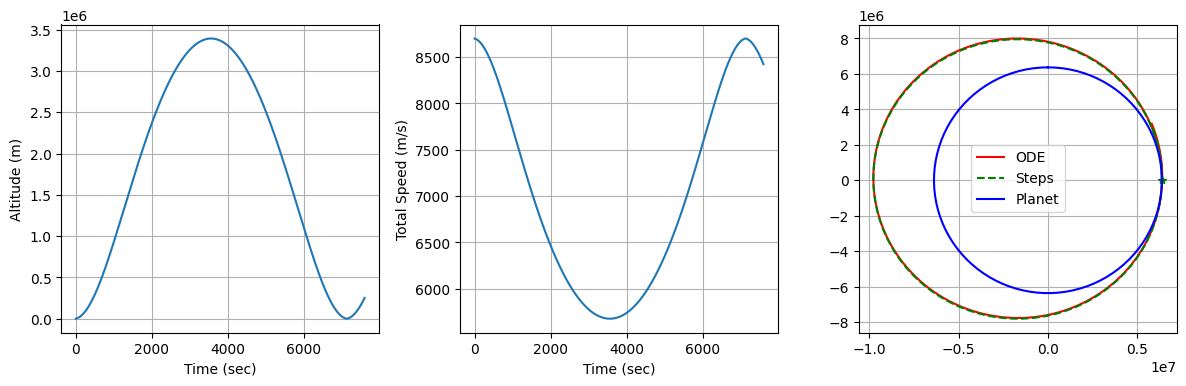

In [162]:
xout = stateout[:, 0]
zout = stateout[:, 1]
altitude = np.sqrt(xout**2 + zout**2) - earth.radius
velxout = stateout[:, 2]
velzout = stateout[:, 3]
velout = np.sqrt(velxout**2 + velzout**2)

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))
ax.flatten()

ax[0].plot(tout, altitude)
ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (m)")
ax[0].grid()

ax[1].plot(tout, velout)
ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].grid()


ax[2].plot(xout, zout, "r-", label="ODE")
ax[2].plot(xsim, zsim, "g--", label="Steps")
ax[2].plot(xout[0], zout[0], "g*")
theta = np.linspace(0, 2 * np.pi, 100)
xplanet = earth.radius * np.sin(theta)
yplanet = earth.radius * np.cos(theta)
ax[2].plot(xplanet, yplanet, "b-", label="Planet")
ax[2].grid()
ax[2].legend()

fig.tight_layout(pad=1.2)
